In [ ]:
import sys

assert sys.version_info >= (3, 7)

from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

from pathlib import Path

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

선형 회귀

In [ ]:
import numpy as np

# 코드의 실행 결과 재현을 위해 난수 시드 고정
np.random.seed(42)

m = 100  # 샘플의 개수
# 균등 분포, [0.0, 1.0) 실수 반환
X = 2 * np.random.rand(m, 1) # 열 벡터
# 표준 정규 분포, -무한대에서 무한대의 모든 실수를 반환하나, 정규 분표 규칙 (68-95-99.7)을 따른다. 노이즈 추가
y = 3 * X + 4 + np.random.randn(m, 1) # 열 벡터

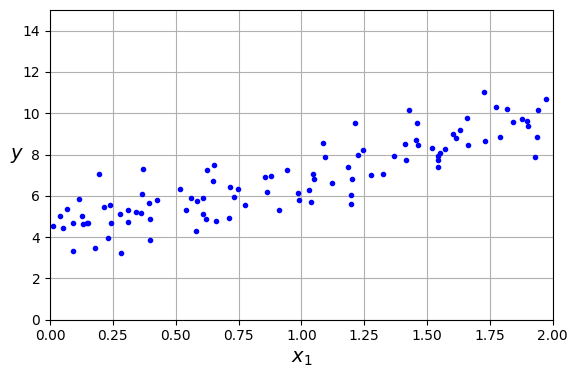

In [ ]:
# x축 = feature, y축 = label

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("generated_data_plot")
plt.show()

In [ ]:
# 닫힌 형태의 방정식에서, 비용 함수를 최소화하는 파라미터를 즉시 찾을 수 있는 정규 방정식 사용

# 데이터 행렬의 맨 앞에 1로만 채워진 열을 추가
# -> 선형 회귀 모델의 가설 y = ax + b에서, 편향 b에 대한 연산 용이하게 처리
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # 각 샘플에 x0 = 1을 추가
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y # 정규 방정식을 통해 최적의 파라미터 계산

In [ ]:
theta_best

array([[4.21509616],
       [2.77011339]])

**y = 3x + 4 + 가우스 노이즈** 에 대한 정규 방정식의 해

array([[4.21509616],
       [2.77011339]])

실제: Θ1 = 3, Θ2 = 4

예측: Θ1 = 4.215, Θ2= 2.770

In [ ]:
X_new = np.array([[0], [2]]) # 2, 1

X_new_b = add_dummy_feature(X_new)

y_predict = X_new_b @ theta_best # x = 0, x = 2에서의 예측값 계산

y_predict

array([[4.21509616],
       [9.75532293]])

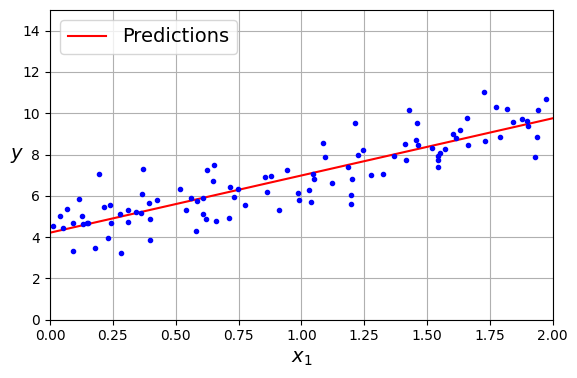

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # 추가 코드
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
save_fig("linear_model_predictions_plot")

plt.show()

In [ ]:
# 사이킷런의 선형 회귀 모델 사용
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

lin_reg.intercept_, lin_reg.coef_ # 가중치, 편향
# (array([4.21509616]), array([[2.77011339]]))

lin_reg.predict(X_new)
# array([[4.21509616],
#        [9.75532293]])

array([[4.21509616],
       [9.75532293]])

In [ ]:
# 이전 정규방정식 풀이에서, 행렬식이 0이 아닌 정사각행렬이 아니라면 역행렬을 구할 수 없기 때문에,
# 특이값 분해를 통해 유사역행렬을 구하여 일반적인 상황에서도 정규방정식으로 풀 수 있다.

theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

정규 방정식은 (n + 1) * (n + 1) 크기의 X.T @ X 의 역행렬을 계산(n = 특성의 개수) ->